In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import requests
import random

from io import StringIO

from UniversoActivos import UniversoActivosEstatico, UniversoActivosDinamico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
import Modelos
Modelos = importlib.reload(Modelos)
import Estrategia
importlib.reload(Estrategia)
from Backtest import BacktestEngine, BacktestRandom

RandomForestModel = Modelos.RandomForestModel
XGBoostModel = Modelos.XGBoostModel

EstrategiaMLEquiponderada = Estrategia.EstrategiaMLEquiponderada
EstrategiaMLMinVarAlphaTilt = Estrategia.EstrategiaMLMinVarAlphaTilt
EstrategiaMLMonteCarlo = Estrategia.EstrategiaMLMonteCarlo
EstrategiaMLEquiponderadaMacro = Estrategia.EstrategiaMLEquiponderadaMacro

### Descarga de tickers actuales del STOXX50

In [2]:
def get_eurostoxx50_tickers():
    url = 'https://en.wikipedia.org/wiki/EURO_STOXX_50'
    headers = {"User-Agent": "Mozilla/5.0 ..."}
    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()

    tables = pd.read_html(StringIO(response.text), flavor='bs4')
    df = next(t for t in tables if 'Ticker' in t.columns)
    return df['Ticker'].tolist()

tickers = get_eurostoxx50_tickers()

# Modelo elegido: XGBoost con estrategia de optimización de pesos por Montecarlo

c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


[Train] 2017-01-06 → 2022-12-30 | AUC=0.5400 | {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'scale_pos_weight': 3, 'subsample': 0.7}
2023-01-06 | VP=10000000 | pesos={'ARGX.BR': 0.12931147480267205, 'ASML.AS': 0.054617988472379905, 'BAYN.DE': 0.024169567423818573, 'DHL.DE': 0.0349415916592671, 'ENI.MI': 0.0427500475716729, 'IFX.DE': 0.03369338320868993, 'INGA.AS': 0.09383924295604651, 'ISP.MI': 0.11957292609831188, 'ITX.MC': 0.1373365260898723, 'MBG.DE': 0.031024419660734374, 'NDA-FI.HE': 0.05987874892918668, 'NOKIA.HE': 0.03522555346104192, 'RHM.DE': 0.02934998731490921, 'RMS.PA': 0.1414512796754241, 'VOW.DE': 0.03283726267597233}
2023-01-13 | VP=10332852 | pesos={'AD.AS': 0.06957870550959122, 'ADYEN.AS': 0.027922291404925484, 'ARGX.BR': 0.15242304242145183, 'DBK.DE': 0.033857398298526645, 'DHL.DE': 0.03904668303602702, 'ENEL.MI': 0.03176977993839059, 'ENI.MI': 0.07350383724777672, 'IFX.DE': 0.02613723344025098, 'INGA.AS': 0.12431021418390581, 

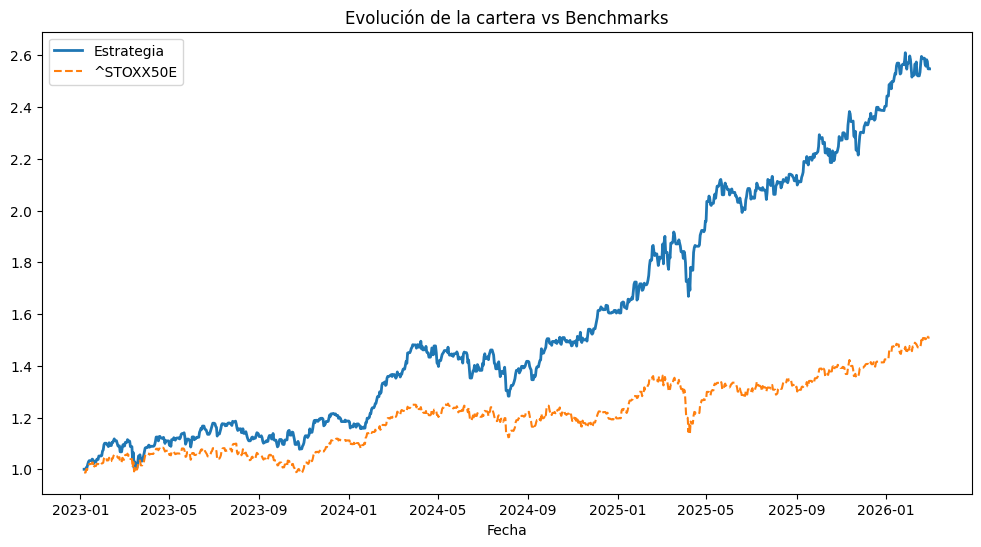

,Estrategia,^STOXX50E
Rentabilidad total,154.73%,52.78%
Rentabilidad anualizada,22.74%,9.73%
Volatilidad anualizada,15.28%,12.18%
Sharpe,1.42,0.82
Sortino,2.09,1.16
Max Drawdown,-14.20%,-16.58%
Calmar,1.60,0.59
Win rate,40.09%,36.87%
Mejor periodo,5.25%,4.26%
Peor periodo,-5.57%,-4.81%


In [3]:
start_date = "2023-01-03"
end_date = "2026-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLMonteCarlo(modelo=modelo, n_activos_obj=15, umbral_salida=22,
                                    n_simulaciones=5000, peso_min=0.02, peso_max=0.15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])

In [6]:
start_date = "2020-01-03"
end_date = "2026-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
provider = YFinanceProvider()

bt_random = BacktestRandom(
    universo=universo,
    proveedor=provider,
    start_date="2022-01-01",
    end_date="2024-01-01",
    nominal=100000,
    n_activos=15
)

res = bt_random.run_montecarlo(
    n_sims=100,
    benchmark="^STOXX50E"
)

plt.figure(figsize=(12, 6))
plt.plot(res["media"].index, res["media"] / res["media"].iloc[0], label="Media 100 simulaciones", linewidth=2)
plt.plot(res["benchmark"].index, res["benchmark"] / res["benchmark"].iloc[0], label="EuroStoxx 50", linestyle="--")
plt.title("Backtest aleatorio vs EuroStoxx 50")
plt.xlabel("Fecha")
plt.ylabel("Valor normalizado")
plt.legend()
plt.grid(True)
plt.show()

KeyboardInterrupt: 

c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr

[Train] 2009-01-09 → 2015-01-02 | AUC=0.5362 | {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'scale_pos_weight': 5, 'subsample': 0.7}
2015-01-09 | VP=10000000 | pesos={'ARGX.BR': 0.06304400086546466, 'ASML.AS': 0.15966368497038919, 'BAYN.DE': 0.10020254030539232, 'BBVA.MC': 0.042867132070472, 'BNP.PA': 0.03395453904054303, 'ENEL.MI': 0.06193894635690152, 'ENI.MI': 0.028278120838474807, 'RHM.DE': 0.04642574232041499, 'SAN.MC': 0.03194248378439305, 'SAN.PA': 0.11124389589138288, 'STLAM.MI': 0.12377244127269058, 'TEF.MC': 0.02794775934602701, 'TTE.PA': 0.02643189195323377, 'UCG.MI': 0.030137649565251487, 'VOW.DE': 0.11214917141896881}
2015-01-16 | VP=10524434 | pesos={'AD.AS': 0.035462716488534364, 'ARGX.BR': 0.16399473756537136, 'ASML.AS': 0.16399473756537136, 'BNP.PA': 0.04518983502808019, 'ENEL.MI': 0.029172719021798275, 'ENGI.PA': 0.03379243416290679, 'ENI.MI': 0.054615674246737786, 'IBE.MC': 0.07598574942698932, 'RHM.DE': 0.026484288045131005, 

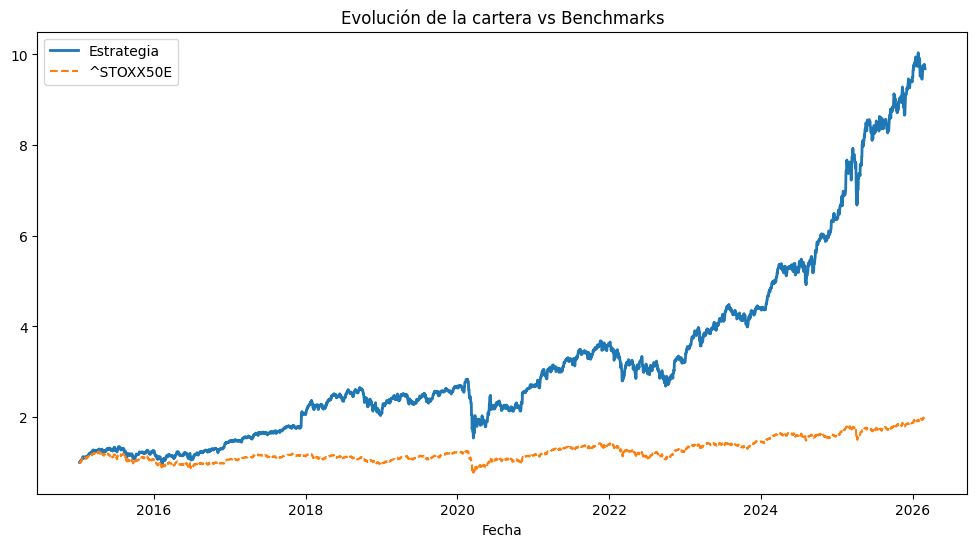

,Estrategia,^STOXX50E
Rentabilidad total,868.39%,101.73%
Rentabilidad anualizada,15.10%,4.44%
Volatilidad anualizada,19.38%,15.67%
Sharpe,0.82,0.36
Sortino,1.18,0.49
Max Drawdown,-45.82%,-38.27%
Calmar,0.33,0.12
Win rate,38.54%,36.67%
Mejor periodo,13.01%,9.24%
Peor periodo,-15.55%,-12.40%


In [5]:
start_date = "2015-01-03"
end_date = "2026-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLMonteCarlo(modelo=modelo, n_activos_obj=15, umbral_salida=22,
                                    n_simulaciones=5000, peso_min=0.02, peso_max=0.15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])

$STM.MI: possibly delisted; no timezone found

1 Failed download:
['STM.MI']: possibly delisted; no timezone found
$STM.MI: possibly delisted; no timezone found

1 Failed download:
['STM.MI']: possibly delisted; no timezone found
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in

[Train] 2004-01-09 → 2010-01-01 | AUC=0.5156 | {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'scale_pos_weight': 3, 'subsample': 0.7}
2010-01-08 | VP=10000000 | pesos={'ASML.AS': 0.15115233044519086, 'BAS.DE': 0.061616573552227646, 'BBVA.MC': 0.14497329023373126, 'CS.PA': 0.02366017329348456, 'DBK.DE': 0.02598076312757706, 'IBE.MC': 0.07105784025165271, 'MBG.DE': 0.03374612710495384, 'MC.PA': 0.07519379702287629, 'OR.PA': 0.059906332506551904, 'RHM.DE': 0.039909786662112264, 'RNO.PA': 0.036079238075769286, 'SAN.MC': 0.15115233044519086, 'STLAM.MI': 0.059746975053450606, 'SU.PA': 0.0429697189877668, 'VOW.DE': 0.022854723237464094}
2010-01-15 | VP=9780040 | pesos={'ADS.DE': 0.14253549878185268, 'ASML.AS': 0.11304629225423965, 'BAS.DE': 0.041705996552072036, 'BBVA.MC': 0.1181787585308085, 'DBK.DE': 0.02483202637835564, 'DHL.DE': 0.03891163873545156, 'IFX.DE': 0.06258712495699346, 'MC.PA': 0.08233609226597444, 'OR.PA': 0.05582969903035395, 'RHM.DE': 

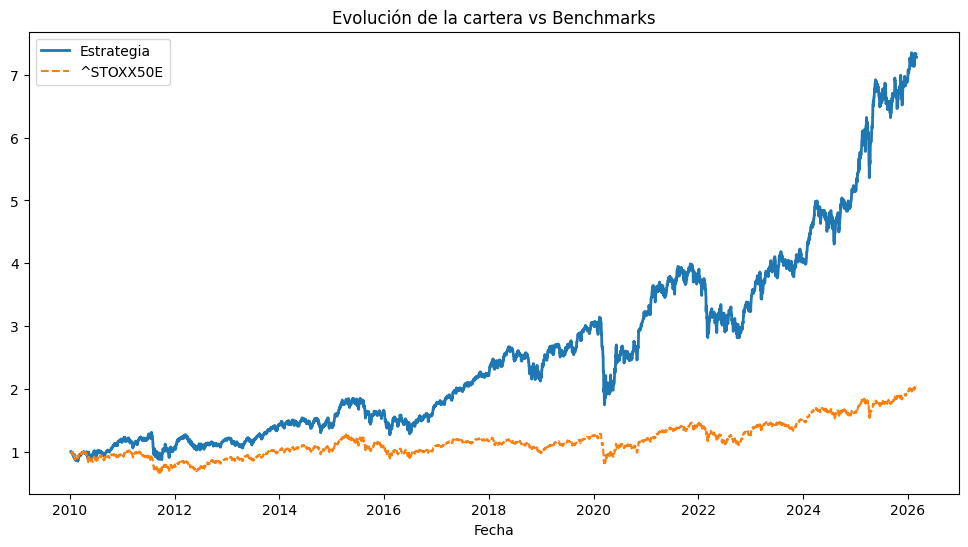

,Estrategia,^STOXX50E
Rentabilidad total,627.80%,103.40%
Rentabilidad anualizada,8.85%,3.08%
Volatilidad anualizada,19.87%,16.59%
Sharpe,0.53,0.27
Sortino,0.75,0.37
Max Drawdown,-44.52%,-38.27%
Calmar,0.20,0.08
Win rate,37.19%,36.02%
Mejor periodo,12.47%,10.35%
Peor periodo,-14.49%,-12.40%


In [6]:
start_date = "2010-01-03"
end_date = "2026-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLMonteCarlo(modelo=modelo, n_activos_obj=15, umbral_salida=22,
                                    n_simulaciones=5000, peso_min=0.02, peso_max=0.15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])

## Simulaciones de la estrategia de los monos locos

[Train] 2018-02-16 → 2024-02-16 | AUC=0.5316 | {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'scale_pos_weight': 3, 'subsample': 0.7}
2024-03-01 | VP=10000000 | pesos={'AD.AS': 0.05116371435348435, 'ADS.DE': 0.0319483875624505, 'ADYEN.AS': 0.023195812565062444, 'ASML.AS': 0.03902154481896533, 'BAYN.DE': 0.03781622585925294, 'BNP.PA': 0.02682806103593492, 'IFX.DE': 0.04143929428972531, 'ISP.MI': 0.15995962573343783, 'ITX.MC': 0.07978641489433004, 'MUV2.DE': 0.15096626426025106, 'NOKIA.HE': 0.04959107680020254, 'PRX.AS': 0.0361999831508073, 'RHM.DE': 0.16001805248188333, 'RI.PA': 0.05701110226098775, 'SAN.PA': 0.05505443993322428}
2024-03-08 | VP=10057180 | pesos={'AD.AS': 0.05124704603566059, 'BAYN.DE': 0.028254837112445353, 'BNP.PA': 0.040893453018482136, 'IFX.DE': 0.030403890241687055, 'INGA.AS': 0.12932333988955091, 'ITX.MC': 0.07126462776174541, 'MC.PA': 0.04668463479060835, 'MUV2.DE': 0.15399467929704647, 'NOKIA.HE': 0.03370373188473933, 'PRX

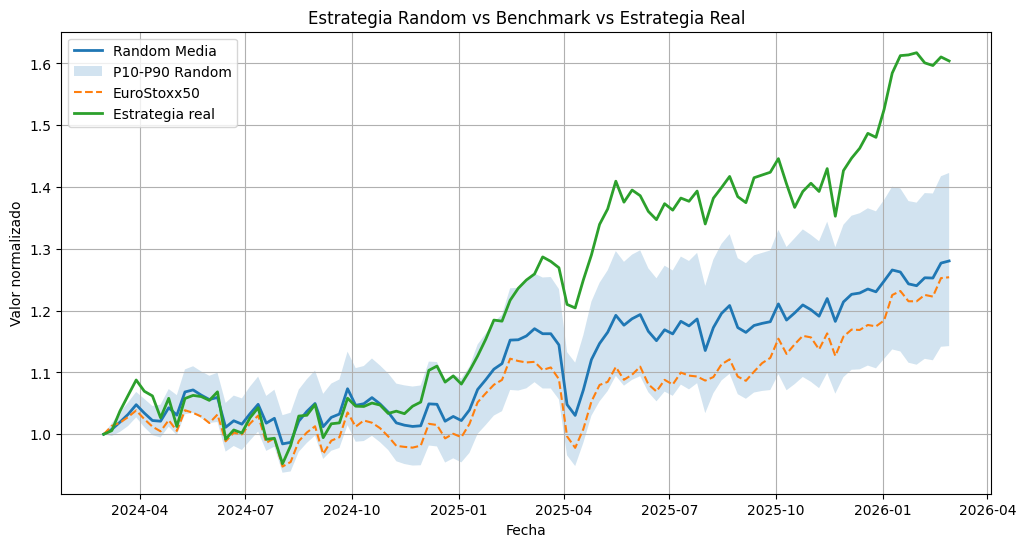

In [3]:
start_date = "2024-03-01"
end_date = "2026-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()

bt_random = BacktestRandom(
    universo=universo,
    proveedor=proveedor,
    start_date=start_date,
    end_date=end_date,
    nominal=10000000,
    n_activos=15
)

res = bt_random.run_montecarlo(n_sims=10000, benchmark="^STOXX50E")

serie_random = res["media"] / res["media"].iloc[0]
serie_p10 = res["p10"] / res["p10"].iloc[0]
serie_p90 = res["p90"] / res["p90"].iloc[0]
serie_bmk = res["benchmark"] / res["benchmark"].iloc[0]

fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLMonteCarlo(modelo=modelo, n_activos_obj=15, umbral_salida=22,
                                    n_simulaciones=5000, peso_min=0.02, peso_max=0.15)
bt_real = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)

serie_real = (
    bt_real._run()
    .set_index("Fecha")["Valor cartera"]
    .sort_index()
    .resample("W-FRI").last()
    .reindex(serie_random.index)
    .ffill()
)
serie_real = serie_real / serie_real.iloc[0]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(serie_random.index, serie_random, label="Random Media", linewidth=2)
plt.fill_between(serie_random.index, serie_p10, serie_p90, alpha=0.2, label="P10-P90 Random")
plt.plot(serie_bmk.index, serie_bmk, "--", label="EuroStoxx50")
plt.plot(serie_real.index, serie_real, label="Estrategia real", linewidth=2)

plt.title("Estrategia Random vs Benchmark vs Estrategia Real")
plt.xlabel("Fecha")
plt.ylabel("Valor normalizado")
plt.legend()
plt.grid(True)
plt.show()

Ahora, simulamos qué habría pasado si hubiéramos usado RF o XGBoost desde el principio

[Train] 2020-02-28 → 2026-02-27 | AUC=0.5391 | {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'scale_pos_weight': 3, 'subsample': 0.7}
2026-03-13 | VP=10000000 | pesos={'ADYEN.AS': 0.03231231821015443, 'ARGX.BR': 0.12443869959554808, 'ASML.AS': 0.06819442981204599, 'BAYN.DE': 0.08419057273477207, 'BBVA.MC': 0.050813548365535054, 'BN.PA': 0.10926064771424167, 'DB1.DE': 0.04923919690632346, 'DBK.DE': 0.02182228823866095, 'ENI.MI': 0.15021750158974245, 'ENR.DE': 0.07826207526245227, 'RHM.DE': 0.02027628734677736, 'SAN.MC': 0.02390062973015137, 'TTE.PA': 0.1406777190540675, 'UCG.MI': 0.02039803240115602, 'WKL.AS': 0.02599605303837119}
2026-03-20 | VP=9943277 | pesos={'ADS.DE': 0.022659912756696828, 'ADYEN.AS': 0.023264633331953936, 'ASML.AS': 0.0988501821646199, 'BAYN.DE': 0.08662383931073503, 'BBVA.MC': 0.060898473156738867, 'BMW.DE': 0.04567825775082254, 'BN.PA': 0.08596771668121815, 'DBK.DE': 0.052128360968494054, 'ENI.MI': 0.16501684205868686, 'EN

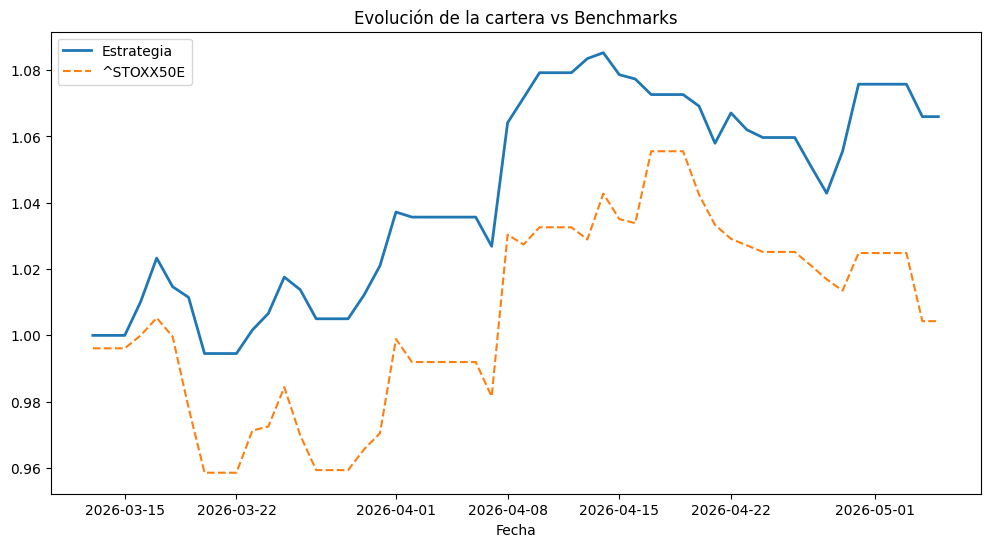

,Estrategia,^STOXX50E
Rentabilidad total,6.60%,0.82%
Rentabilidad anualizada,35.50%,3.97%
Volatilidad anualizada,13.44%,18.02%
Sharpe,2.33,0.30
Sortino,4.68,0.54
Max Drawdown,-3.90%,-4.85%
Calmar,9.09,0.82
Win rate,30.19%,24.53%
Mejor periodo,3.63%,4.97%
Peor periodo,-1.68%,-2.14%


(DatetimeIndex(['2026-03-13', '2026-03-14', '2026-03-15', '2026-03-16',
                '2026-03-17', '2026-03-18', '2026-03-19', '2026-03-20',
                '2026-03-21', '2026-03-22', '2026-03-23', '2026-03-24',
                '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-28',
                '2026-03-29', '2026-03-30', '2026-03-31', '2026-04-01',
                '2026-04-02', '2026-04-03', '2026-04-04', '2026-04-05',
                '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09',
                '2026-04-10', '2026-04-11', '2026-04-12', '2026-04-13',
                '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17',
                '2026-04-18', '2026-04-19', '2026-04-20', '2026-04-21',
                '2026-04-22', '2026-04-23', '2026-04-24', '2026-04-25',
                '2026-04-26', '2026-04-27', '2026-04-28', '2026-04-29',
                '2026-04-30', '2026-05-01', '2026-05-02', '2026-05-03',
                '2026-05-04', '2026-05-05'],
               dtyp

In [3]:
start_date = "2026-03-13"
end_date = "2026-05-05"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLMonteCarlo(modelo=modelo, n_activos_obj=15, umbral_salida=22,
                                    n_simulaciones=500000, peso_min=0.02, peso_max=0.15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)
engine.print_results(bmks=["^STOXX50E"])

[Train] 2020-02-28 → 2026-02-27 | AUC=0.5476 | {'class_weight': {0: 1, 1: 3}, 'max_depth': 3, 'max_features': 0.8, 'min_samples_leaf': 0.05, 'n_estimators': 150}
2026-03-13 | VP=10000000 | pesos={'ASML.AS': 0.06666666666666667, 'ENR.DE': 0.06666666666666667, 'BAYN.DE': 0.06666666666666667, 'SAN.MC': 0.06666666666666667, 'ADYEN.AS': 0.06666666666666667, 'SGO.PA': 0.06666666666666667, 'ADS.DE': 0.06666666666666667, 'WKL.AS': 0.06666666666666667, 'DBK.DE': 0.06666666666666667, 'RACE.MI': 0.06666666666666667, 'UCG.MI': 0.06666666666666667, 'IFX.DE': 0.06666666666666667, 'EL.PA': 0.06666666666666667, 'BBVA.MC': 0.06666666666666667, 'SAP.DE': 0.06666666666666667}
2026-03-20 | VP=9593690 | pesos={'UCG.MI': 0.06666666666666667, 'EL.PA': 0.06666666666666667, 'SAP.DE': 0.06666666666666667, 'SAN.MC': 0.06666666666666667, 'RACE.MI': 0.06666666666666667, 'IFX.DE': 0.06666666666666667, 'ASML.AS': 0.06666666666666667, 'SGO.PA': 0.06666666666666667, 'ADS.DE': 0.06666666666666667, 'WKL.AS': 0.066666666

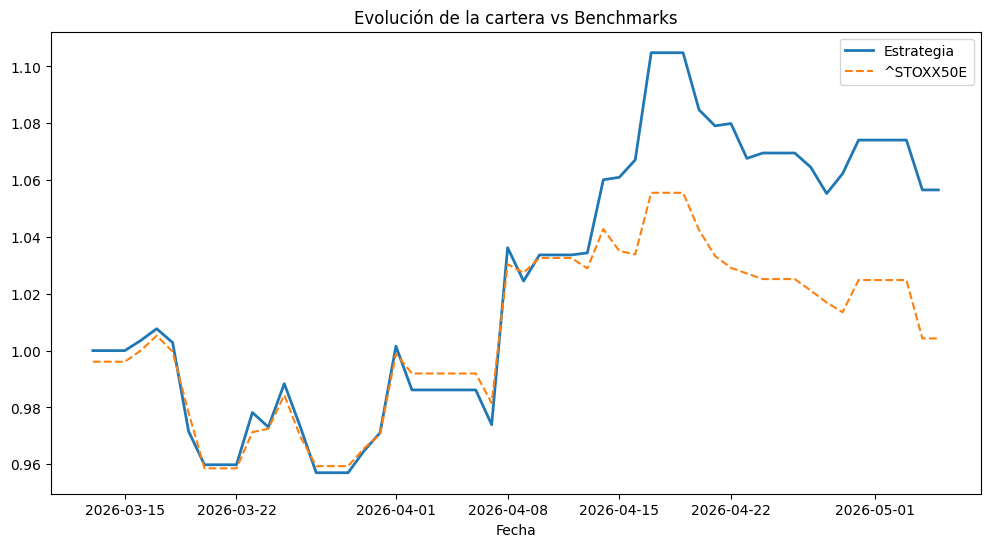

,Estrategia,^STOXX50E
Rentabilidad total,5.65%,0.82%
Rentabilidad anualizada,29.89%,3.97%
Volatilidad anualizada,23.04%,18.02%
Sharpe,1.25,0.30
Sortino,2.39,0.54
Max Drawdown,-5.03%,-4.85%
Calmar,5.95,0.82
Win rate,33.96%,24.53%
Mejor periodo,6.39%,4.97%
Peor periodo,-3.11%,-2.14%


(DatetimeIndex(['2026-03-13', '2026-03-14', '2026-03-15', '2026-03-16',
                '2026-03-17', '2026-03-18', '2026-03-19', '2026-03-20',
                '2026-03-21', '2026-03-22', '2026-03-23', '2026-03-24',
                '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-28',
                '2026-03-29', '2026-03-30', '2026-03-31', '2026-04-01',
                '2026-04-02', '2026-04-03', '2026-04-04', '2026-04-05',
                '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09',
                '2026-04-10', '2026-04-11', '2026-04-12', '2026-04-13',
                '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17',
                '2026-04-18', '2026-04-19', '2026-04-20', '2026-04-21',
                '2026-04-22', '2026-04-23', '2026-04-24', '2026-04-25',
                '2026-04-26', '2026-04-27', '2026-04-28', '2026-04-29',
                '2026-04-30', '2026-05-01', '2026-05-02', '2026-05-03',
                '2026-05-04', '2026-05-05'],
               dtyp

In [4]:
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = RandomForestModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=15, umbral_salida=22)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)
engine.print_results(bmks=["^STOXX50E"])